# **Real-time inference**

In [ ]:
RECYCLING_TIPS = {
    "glass": (
        "Put it in the green glass bin.\n"
        "Rinse thoroughly to remove food residue.\n"
        "Separate clear, brown, and green glass if required."
    ),
    "paper": (
        "Put it in the blue paper bin.\n"
        "Keep it dry and clean.\n"
        "Avoid recycling greasy or wet paper."
    ),
    "cardboard": (
        "Fold it to save space and put it with paper.\n"
        "Remove tape, stickers, and labels if possible.\n"
        "Keep cardboard dry before recycling."
    ),
    "plastic": (
        "Rinse containers before recycling.\n"
        "Check for recycling symbols (1\u20137).\n"
        "Remove caps or lids when required by local rules."
    ),
    "metal": (
        "Crush cans to save space.\n"
        "Aluminum and steel cans are usually recyclable.\n"
        "Rinse food containers before disposal."
    ),
    "electronics": (
        "Do not throw electronics in regular trash.\n"
        "Take them to an e-waste collection center.\n"
        "Remove batteries before recycling if possible."
    ),
    "batteries": (
        "Never place batteries in regular recycling bins.\n"
        "Use designated battery recycling drop-off points.\n"
        "Tape battery terminals for safety if needed."
    ),
    "organic": (
        "Use compost bins for food scraps and yard waste.\n"
        "Avoid adding plastic or metal items.\n"
        "Composting helps reduce landfill waste."
    ),
    "clothing": (
        "Donate reusable clothes whenever possible.\n"
        "Use textile recycling bins for damaged fabrics.\n"
        "Wash items before donating or recycling."
    ),
    "trash": (
        "This item is not recyclable.\n"
        "Try to reduce waste or reuse materials.\n"
        "Dispose of it in the general waste bin."
    ),
}

In [ ]:
def preprocess_for_inference(image_input):
    """
    Accepts: path(str), bytes, or PIL Image
    Returns: array (model ready)
    """
    if isinstance(image_input, str):
        img = Image.open(image_input).convert("RGB")
    elif isinstance(image_input, bytes):
        img = Image.open(io.BytesIO(image_input)).convert("RGB")
    else:
        img = image_input.convert("RGB")

    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

def production_predict(image_input, model, top_k=3):
    """
    Inference is ready for production with top-k predictions
    """
    processed = preprocess_for_inference(image_input)

    predictions = model.predict(processed, verbose=0)[0]

    # top-k predictions
    top_indices = predictions.argsort()[-top_k:][::-1]

    result = {
        "prediction": classes[top_indices[0]],
        "confidence": float(predictions[top_indices[0]]),
        "tip": RECYCLING_TIPS[classes[top_indices[0]]],
        "top_3": [
            {
                "class": classes[i],
                "probability": float(predictions[i])
            }
            for i in top_indices
        ]
    }

    return result

Saving plastic_990.jpg to plastic_990.jpg
User uploaded file "plastic_990.jpg" with length 18437 bytes


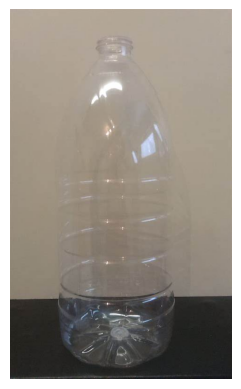


 Category: plastic
Confidence: 75.9%
Tips-Guidance: Rinse containers before recycling.
Check for recycling symbols (1–7).
Remove caps or lids when required by local rules.

Top 3 probability:
  plastic: 75.9%
  glass: 24.1%
  metal: 0.0%


In [ ]:
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Pass the uploaded bytes directly to the prediction function
  result = production_predict(uploaded[fn], model)
# print the image
  img = Image.open(fn)
  plt.imshow(img)
  plt.axis('off')
  plt.show()
  print(f"\n Category: {result['prediction']}")
  print(f"Confidence: {result['confidence']:.1%}")
  print(f"Tips-Guidance: {result['tip']}")
  print(f"\nTop 3 probability:")
  for item in result['top_3']:
      print(f"  {item['class']}: {item['probability']:.1%}")